# Taller Conjunto: Flow Matching y Modelos de Difusión

Este taller combina dos paradigmas de modelado generativo:

- **Parte 1**: implementaremos *flow matching* desde cero sobre un conjunto de datos sintético en 2D (Two Moons).
- **Parte 2**: aplicaremos *modelos de difusión* a un problema real de finanzas, generando escenarios de mercado para un conjunto de ETFs.

## Parte 1: Flow Matching

## Fundamentos teóricos

1. **La ecuación de flujo**:
   Como en los CNFs:

   $$\frac{dx_t}{dt} = v_\theta(x_t, t)$$

   Donde:
   - $x_t$ es nuestra imagen mientras se va transformando
   - $t$ es el tiempo (entre 0 y 1); en $t=0$, $p(x_0)$ es $N(0,1)$; en $t=1$, $p(x_1)$ es la distribución objetivo que queremos muestrear.
   - $v_\theta$ es un campo de velocidad que vamos a parametrizar con una red neuronal, y que determinará la dirección en la que hay que moverse para muestrear de la distribución objetivo.

2. **La trayectoria** (interpolación lineal entre ruido y dato)

   Elegimos un interpolante, $x_t$, que cumple:

   $$x_t = (1-t)x_0 + tx_1$$

   Donde:
   - $x_0$ es ruido aleatorio (nuestro punto de partida)
   - $x_1$ es una imagen real de galaxia (nuestro objetivo)

3. **Función de pérdida**:
   Entrenamos nuestro modelo para minimizar:

   $$L = \mathbb{E}_{t,x_0,x_1} \left[ \left\| v_\theta(x_t, t) - u(x_0,x_1,t) \right\|^2 \right]$$

   Donde, dado el interpolante lineal, el campo de velocidad verdadero es $u(x_0, x_1,t) = x_1 - x_0$. Esto le enseña al modelo a predecir la dirección correcta de cambio en cada paso.

## 0. Importación de librerias 

Vamos a importar todas las librerías utilizadas en el laboratorio

In [ ]:
%pip install torch torchvision 
%pip install matplotlib
%pip install numpy
%pip install tqdm

/Users/tomassierra/Documents/Universidad/MMLMonioria/.venv/bin/python: No module named uv
Note: you may need to restart the kernel to use updated packages.
/Users/tomassierra/Documents/Universidad/MMLMonioria/.venv/bin/python: No module named uv
Note: you may need to restart the kernel to use updated packages.
/Users/tomassierra/Documents/Universidad/MMLMonioria/.venv/bin/python: No module named uv
Note: you may need to restart the kernel to use updated packages.
/Users/tomassierra/Documents/Universidad/MMLMonioria/.venv/bin/python: No module named uv
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import torch
import torchdiffeq
import torch.utils.data as data

import matplotlib.pyplot as plt
import numpy as np

from tqdm import tqdm
import torch.optim as optim
from IPython.display import clear_output

## 1. Creación de datos

Antes de cualquier cosa tenemos que definir un conjunto de datos que vamos a utilizar para el entrenamiento y prueba de la red neuronal. En primera instancia vamos a generar datos de la forma de Two Moons. Estos datos se utilizan para diferentes entrenamientos como clasificación no supervisada y supervisada. Pero en este caso también son lo suficientemente llamativos para permitir una generación de imágenes de la forma 'Two Moons'.

La siguiente función genera n sets de puntos (x,y) que toman la forma de las 'Two moons'. También devuelve la información de clasificación de los puntos; sin embargo, en este caso no vamos a necesitar esa información ya que es para nosotros más valiosa la forma de los puntos en general.

In [ ]:
def two_moons(n: int, sigma: float = 5e-2):
    theta = 2 * torch.pi * torch.rand(n)
    label = (theta > torch.pi).float()

    x = torch.stack(
        (
            torch.cos(theta) + label - 1 / 2,
            torch.sin(theta) + label / 2 - 1 / 4,
        ),
        axis=-1,
    )

    return torch.normal(x, sigma), label


samples, _ = two_moons(16384)

Ahora veamos la forma de los datos

In [ ]:
samples.shape

torch.Size([16384, 2])

Y veamos cómo se distribuyen los diferentes puntos de todos los puntos generados

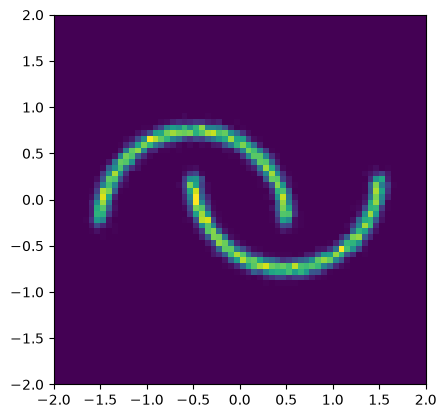

In [ ]:
plt.figure(figsize=(4.8, 4.8))
plt.hist2d(*samples.T, bins=64, range=((-2, 2), (-2, 2)))
plt.show()

## 2. Definición de interpolante y red neuronal

Antes de que definamos una red neuronal para el problema debemos entender cuál es el propósito que queremos que cumpla nuestra red. Por lo tanto, vamos a modelar el movimiento ideal de los datos desde el ruido hasta nuestra distribución final (Two Moons).

/var/folders/6b/y192wv357j10zzrb0tnpmfdw0000gn/T/ipykernel_1693/3049731746.py:26: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x1 = torch.tensor(x1).float()


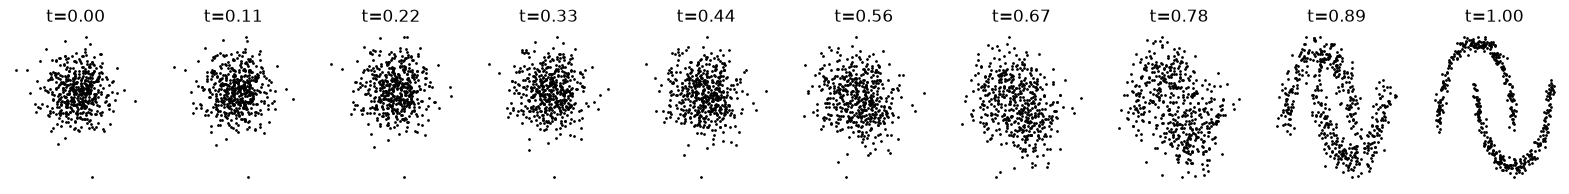

In [ ]:
def interpolant(x0, x1, t):
    """

    Implementa la interpolación lineal entre el ruido (x0) y el dato (x1).

    En t=0: deberíamos obtener ruido puro (x0)
    En t=1: deberíamos obtener el dato real (x1)
    En t=0.5: deberíamos obtener una mezcla 50/50

    Args:
        x0: Punto de partida (ruido), shape: (batch_size, ...)
        x1: Punto final (dato), shape: (batch_size, ...)
        t: Parámetro de tiempo, shape: (batch_size,) o escalar

    Returns:
        x_t: Muestras interpoladas en el tiempo t
    """

    # Implementa la interpolación lineal entre x0 y x1 usando el parámetro t
    #------#
    return ((1-t)*x0) + (t*x1)
    #------#

fig, axs = plt.subplots(1, 10, figsize=(20, 2))

x1, _ = two_moons(500,)
x1 = torch.tensor(x1).float()
x0  = torch.randn_like(x1)
t = torch.tensor(np.linspace(0., 1., 10))
for i, ax in enumerate(axs):
    xt = interpolant(x0,x1,t[i])
    ax.scatter(xt[:,0], xt[:,1],s=1, color='k')
    ax.axis('off')
    ax.set_title(f't={t[i]:.2f}')

Como se ve en esta imagen los puntos inician distribuidos uniformemente para, poco a poco y a medida que pasa el tiempo, desplazarse a su destino final en una trayectoria lineal.

**Pregunta:** Si podemos generar este movimiento sin entrenar nada, ¿cuál es la razón de necesitar entrenar una red neuronal?

Ahora entendida la necesidad de la red neuronal vamos a modelarla. En la siguiente clase se va a almacenar nuestra red y se necesita definir dos funciones importantes:

1. La función de inicialización: Con la ayuda de las librerías nn de pytorch defina una red neuronal de las siguientes características

    - Una capa de entrada
    - Tres capas ocultas
    - Una capa de salida
    - Funciones de activación SiLU

2. La función forward: Esta función recibirá un punto en el espacio $x_t$ y un tiempo $t$ y los pasará por la red.

**Pregunta:** ¿Cuáles son las dimensiones de las diferentes capas de la red? (Pista: ¿Cuántas neuronas hay en cada capa?)

In [ ]:
import torch.nn as nn

class VelocityNetwork(nn.Module):
    def __init__(self, hidden_dim=64):
        super().__init__()
        # TODO: Crea una red neuronal que reciba como entrada:
        # - Posición 2D (x_t)
        # - Tiempo 1D (t)
        #
        # Salida: vector de velocidad 2D
        #
        # Guarda esto en self.net como un nn.Sequential

        #------#
        self.net = nn.Sequential(
            nn.Linear(3, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 2)
        )
        #------#

    def forward(self, xt, t):
        # TODO: Combina xt y t en un único tensor de entrada y pásalo por la
        # red que predice la velocidad
        
        #-----#
        if t.dim() == 1:
            t = t.unsqueeze(1)
        xt = torch.cat([xt, t], dim=1)
        v = self.net(xt)
        return v
        #-----#

Ahora vamos a crear el modelo e ingresarlo dentro del dispositivo de pytorch. 

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

velocity_nn = VelocityNetwork(
    hidden_dim=128,
).to(device)

t=torch.tensor(500*[0.5],dtype=torch.float32, device=device)

#Revisar que la salida de la red neuronal tenga la forma esperada
assert velocity_nn(
    xt=x1.to(device),
    t=t,
).shape == (500, 2), "Esperaba una forma de (500, 2) pero tenía una forma diferente"

Usando dispositivo: cpu


## 3. Definir el modelo Flow Matching

La siguiente clase se va a utilizar como definición del modelo de flow matching. En ella van a encontrar diferentes funciones para completar. La más importante que hay que tener en cuenta es la función de pérdida.

Para calcular la función de pérdida:

1. **Muestrea un par de entrenamiento aleatorio**: Toma ruido $x_0$ y dato real $x_1$
2. **Elige un tiempo aleatorio**: Escoge $t$ uniformemente entre 0 y 1 para estimar por Monte Carlo el valor esperado sobre el tiempo.
3. **Obtén el dato interpolado**: $x_t = (1-t)x_0 + tx_1$
4. **Evalúa la red de predicción de velocidad**: "¿Qué velocidad predices en $(x_t, t)$?"
5. **Compara con la verdad, conociendo $x_1$**
6. **Actualiza los pesos**: Usa backpropagation para mejorar las predicciones


In [ ]:
class FlowMatching(nn.Module):
    def __init__(self, velocity_network, device='cuda'):
        super().__init__()
        self.velocity_net = velocity_network
        self.device = device

    def sample_time(self, batch_size):
        """Tomar un tiempo aleatorio t entre 0 y 1 para cada muestra en el batch"""
        return torch.rand(batch_size, device=self.device)

    def interpolate(self, x0, x1, t):
        """
        Interpolación lineal entre el ruido (x0) y el dato (x1).
        En t=0: retorna x0 (ruido)
        En t=1: retorna x1 (dato)
        """

        # TODO: Llenar el interpolante con las dimensiones correctas
        #----#
        if t.dim() == 1:
          t = t.view(t.shape[0], *([1] * (x1.dim() - 1)))
        return ((1-t)*x0) + (t*x1)
        #----#

    def compute_target_velocity(self, x0, x1, t):
        """
        Calcula el campo de velocidad objetivo que la red neuronal debe aprender.

        Piensa en esto: si tenemos x_t = (1-t)*x0 + t*x1,
        ¿cuál es dx_t/dt (la derivada con respecto al tiempo)?
        """
        # Your code here
        #----#
        return x1 - x0
        #----#

    def compute_loss(self, x1,):
        """
        Calcula la pérdida de flow matching.

        Args:
            x1: muestras de datos

        Returns:
            Valor de la pérdida
        """

        # TODO: Calcular la pérdida de flow matching usando las funciones definidas anteriormente
        #----#
        x0 = torch.randn_like(x1)
        t = self.sample_time(x1.shape[0])
        xt = self.interpolate(x0, x1, t)
        v_pred = self.velocity_net(xt, t)
        v_target = self.compute_target_velocity(x0, x1, t)
        loss = torch.mean((v_pred - v_target)**2)
        return loss
        #----#


    def sample(self, target_shape=(2,), num_samples=10, num_steps=200):

      """
        Genera muestras integrando el campo de velocidad aprendido.

        Args:
            num_samples: Número de muestras a generar
            num_steps: Número de pasos de integración

        Returns:
            Muestras generadas
        """


      self.velocity_net.eval()

      x0 = torch.randn(num_samples, *target_shape, device=self.device)
      t = torch.tensor([0.0, 1.0], device=self.device)

      def f(t, x):
          t_batch = t.repeat(num_samples)
          return self.velocity_net(x, t_batch)

      return torchdiffeq.odeint(f, x0, t, method='dopri5')[-1]


Ahora vamos a instanciar el modelo

In [ ]:
fm = FlowMatching(
    velocity_network=velocity_nn,
    device=device,
)

Primero, verifiquemos que podemos llamar a compute_loss. Si nuestros datos están estandarizados correctamente, deberíamos esperar que una red de velocidad inicializada aleatoriamente retorne algo del orden de 1. Siempre presta atención a los valores iniciales de la función de pérdida, ya que valores enormes o diminutos usualmente indican bugs.


In [ ]:
fm.compute_loss(
    x1=x1.to(device),
)

tensor(1.5232, grad_fn=<MeanBackward0>)

Ahora revisemos el solucionador de ODE para generar datos.

In [ ]:
samples = fm.sample(
   num_samples=500,

).detach().cpu().numpy()

assert samples.shape == (500, 2), "Esperaba una forma de (500, 2) pero tenía una forma diferente"

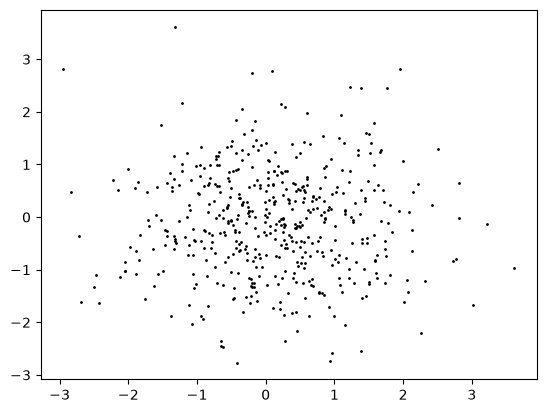

In [ ]:
plt.scatter(
    samples[:,0],
    samples[:,1],
    c='k',
    s=1,
)

**Pregunta:** Porque los datos tienen una distribución aleatoria

Ahora vamos a entrenar la red

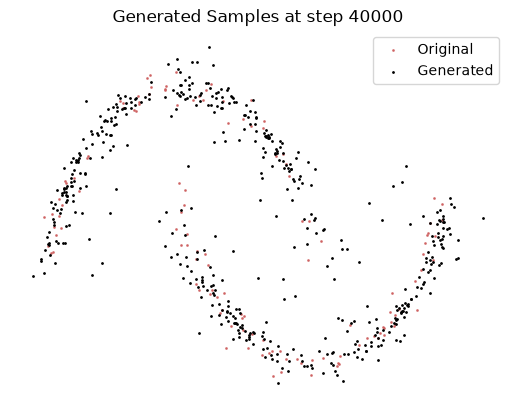

Training: 100%|██████████| 40000/40000 [01:12<00:00, 550.12it/s, Loss=1.0099]


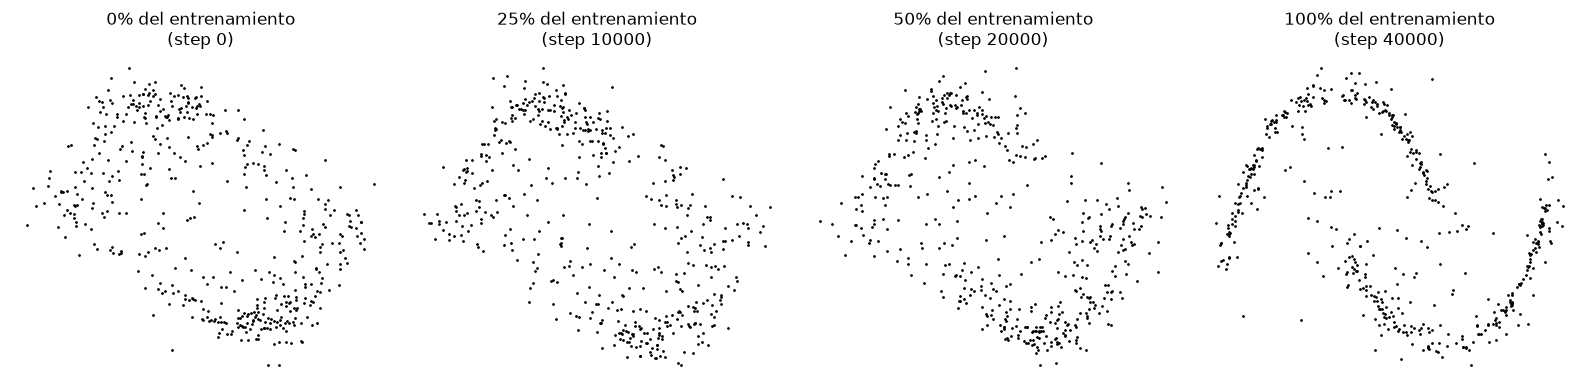

In [ ]:
optimizer = torch.optim.AdamW(fm.parameters(), lr=1.e-4, weight_decay=1e-4)
total_steps = 40_000
generate_every = 100
batch_size = 128
losses = []

# Puntos del entrenamiento en los que queremos guardar una imagen de las muestras generadas
checkpoint_steps = {0, total_steps // 4, total_steps // 2, total_steps}
snapshots = {}

fm.train()

# Muestra de la red antes de entrenar (step=0)
snapshots[0] = fm.sample(num_samples=500).detach().cpu().numpy()
fm.velocity_net.train()

step = 0
with tqdm(total=total_steps, desc="Training") as pbar:
    while step < total_steps:
        x, label = two_moons(batch_size)
        x = x.to(device)  # Move data to device
        loss = fm.compute_loss(x).mean()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(fm.parameters(), max_norm=1.0)


        optimizer.step()
        optimizer.zero_grad()


        pbar.set_postfix({
                'Loss': f'{loss:.4f}',
            })
        pbar.update(1)
        step += 1
        losses.append(loss.detach())

        if step in checkpoint_steps:
            snapshots[step] = fm.sample(num_samples=500).detach().cpu().numpy()
            fm.velocity_net.train()

        if step % generate_every == 0:
            print(f"\nGenerating samples at step {step}...")

            samples = fm.sample(
                num_samples=500,
            ).detach().cpu().numpy()
            clear_output(wait=True)
            plt.scatter(
                x[:,0].cpu().numpy(),
                x[:,1].cpu().numpy(),
                c='indianred',
                s=1,
                alpha=0.8,
                label='Original'
            )
            plt.scatter(
                samples[:,0],
                samples[:,1],
                c='k',
                s=1,
                label='Generated'
            )
            plt.legend()
            plt.title(f'Generated Samples at step {step}')
            plt.axis('off')

            plt.show()
            fm.velocity_net.train()

    losses = torch.stack(losses)

# Comparación final del progreso del entrenamiento: 0%, 25%, 50% y 100%
fig, axs = plt.subplots(1, len(checkpoint_steps), figsize=(4 * len(checkpoint_steps), 4))
for ax, step_i in zip(axs, sorted(checkpoint_steps)):
    pct = int(100 * step_i / total_steps)
    ax.scatter(snapshots[step_i][:, 0], snapshots[step_i][:, 1], c='k', s=1)
    ax.set_title(f'{pct}% del entrenamiento\n(step {step_i})')
    ax.axis('off')
plt.tight_layout()
#Si desea guardar la imagen en su computadora, descomente la siguiente línea y cambie el nombre del archivo según sea necesario
#plt.savefig('progreso_entrenamiento_two_moons.png', dpi=150, bbox_inches='tight')
plt.show()

Ahora generemos unas muestras con la red entrenada

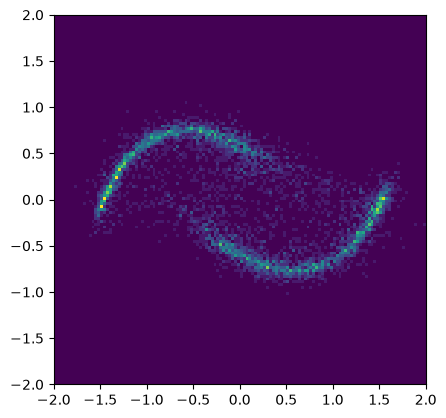

In [ ]:
samples = fm.sample(
    num_samples=5_000,
).detach().cpu().numpy()


plt.figure(figsize=(4.8, 4.8))
plt.hist2d(*samples.T, bins=128, range=((-2, 2), (-2, 2)))
plt.show()

**Pregunta:** Que puede observar de los datos generados por el modelo

Observemos la pérdida con respecto a las épocas

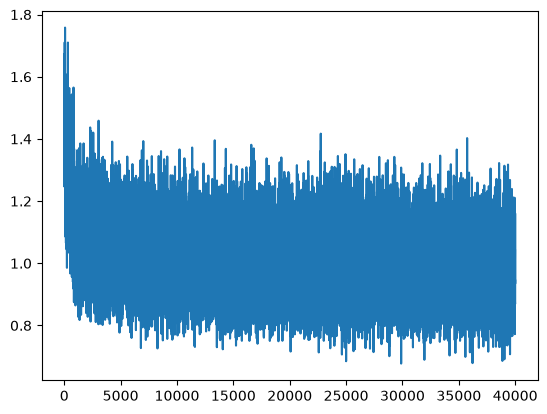

In [ ]:
plt.plot(losses.cpu())

## 4. Preguntas finales

1. Todo lo implementado aquí funciona sobre puntos 2D. ¿Qué tendría que cambiar en la arquitectura de la red de velocidad (no en la lógica de FlowMatching) para que este mismo método funcione sobre imágenes de galaxias de 144x144 píxeles?

2. ¿Qué esperarías que pasara con la calidad de las muestras generadas si aumentas el sigma del ruido en two_moons (la dispersión de los datos reales)? 

## Parte 2: Modelos de Difusión para Mercados Financieros

Las partes del código que se deben completar estarán marcadas con un #TODO.

In [1]:
# Empecemos instalando los paquetes que vamos a utilizar
!pip install numpy pandas jax flax optax matplotlib seaborn scikit-learn yfinance diffrax

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.7/199.7 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.6/77.6 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 72.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.5/85.5 MB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 8.4 MB/s eta 0:00:00
  Attempting uninstall: jaxlib
    Found existing installation: jaxlib 0.7.2
    Uninstalling jaxlib-0.7.2:
      Successfully uninstalled jaxlib-0.7.2
  Attempting uninstall: jax
    Found existing installation: jax 0.7.2
    Uninstalling jax-0.7.2:
      Successfully uninstalled jax-0.7.2


Los modelos de difusión son muy útiles para adaptar cualquier proceso de generación de datos, no solamente imágenes. En este taller mostraremos su flexibilidad en una aplicación financiera.

En mercados financieros es fundamental analizar el riesgo que suponen las inversiones que se tienen en un conjunto de activos. Por lo anterior, una de las tareas más importantes en la gerencia de riesgo financiero corresponde a simular escenarios del mercado de interés y analizar qué podría pasar en los peores días posibles de acuerdo con los datos históricos.

Tradicionalmente, este proceso de simulación se suele realizar utilizando métodos de montecarlo. Sin embargo, estos suelen ser computacionalmente demandantes, por lo cual los modelos generativos son útiles para acelerar estos simuladores.

Empecemos importando las librerías que vamos a utilizar para este taller:

In [2]:
from functools import partial
from typing import Dict

import jax
import jax.numpy as jnp
import flax.linen as nn
import optax

import pandas as pd
import yfinance as yf

from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
from tqdm import trange
import numpy as onp
import seaborn as sns

from matplotlib.gridspec import GridSpec

Para este caso, analizaremos el mercado global de ETFs, los cuales corrseponden a índices bursátiles que se transan en todo el mundo con la intención de poder hacer un análisis de riesgo del mercado globalmente.

En particular, contaremos con los siguientes ETFs:

- SPY (SPDR S&P 500 ETF Trust): sigue el índice S&P 500, representando las principales empresas de gran capitalización de Estados Unidos.
- QQQ (Invesco QQQ Trust): sigue el índice NASDAQ-100, compuesto principalmente por empresas tecnológicas y de crecimiento.
- IWM (iShares Russell 2000 ETF): representa empresas estadounidenses de pequeña capitalización (small caps).
- EFA (iShares MSCI EAFE ETF): agrupa acciones de mercados desarrollados fuera de Estados Unidos y Canadá, como Europa, Australia y Japón.
- EEM (iShares MSCI Emerging Markets ETF): representa acciones de mercados emergentes, incluyendo países como China, India, Brasil y México.
- TLT (iShares 20+ Year Treasury Bond ETF): sigue bonos del Tesoro de Estados Unidos con vencimientos superiores a 20 años.
- HYG (iShares iBoxx $ High Yield Corporate Bond ETF): representa bonos corporativos de alto rendimiento (high yield o bonos basura).
- GLD (SPDR Gold Shares): busca replicar el precio del oro físico.
- USO (United States Oil Fund): sigue el comportamiento del precio del petróleo (WTI) mediante contratos de futuros.
- VNQ (Vanguard Real Estate ETF): representa el mercado inmobiliario estadounidense mediante un portafolio de REITs (Real Estate Investment Trusts).

Además, para cada uno de estos ETF consideraremos tres características relevantes: retorno, volatilidad (intradía) y volumen transado en cada uno de los días.

In [3]:
tickers = [
    "SPY",
    "QQQ",
    "IWM",
    "EFA",
    "EEM",
    "TLT",
    "HYG",
    "GLD",
    "USO",
    "VNQ",
]
n_assets = len(tickers)
n_features = 3   # Retornos, volatilidad, volumen

data = yf.download(
    tickers,
    start="2014-01-01",
    end="2025-01-01",
    auto_adjust=True
)

# Precios de cierre
close = data["Close"]
# Retornos
returns = onp.log(close / close.shift(1))
# Volatilidad
volatility = (data["High"] - data["Low"]) / close
# Volumen
log_volume = onp.log(data["Volume"])


valid_index = (
    returns.notna().all(axis=1)
    & volatility.notna().all(axis=1)
    & log_volume.notna().all(axis=1)
)


returns = returns.loc[valid_index]
volatility = volatility.loc[valid_index]
log_volume = log_volume.loc[valid_index]


financial_data = jnp.array(
    onp.stack(
        [
            returns.values,
            volatility.values,
            log_volume.values,
        ],
        axis=-1,
    )
)

print(financial_data.shape)

[*********************100%***********************]  10 of 10 completed


(2767, 10, 3)


Veamos los histogramas para la distribucion de cada una de las características que estamos analizando de cada ETF.

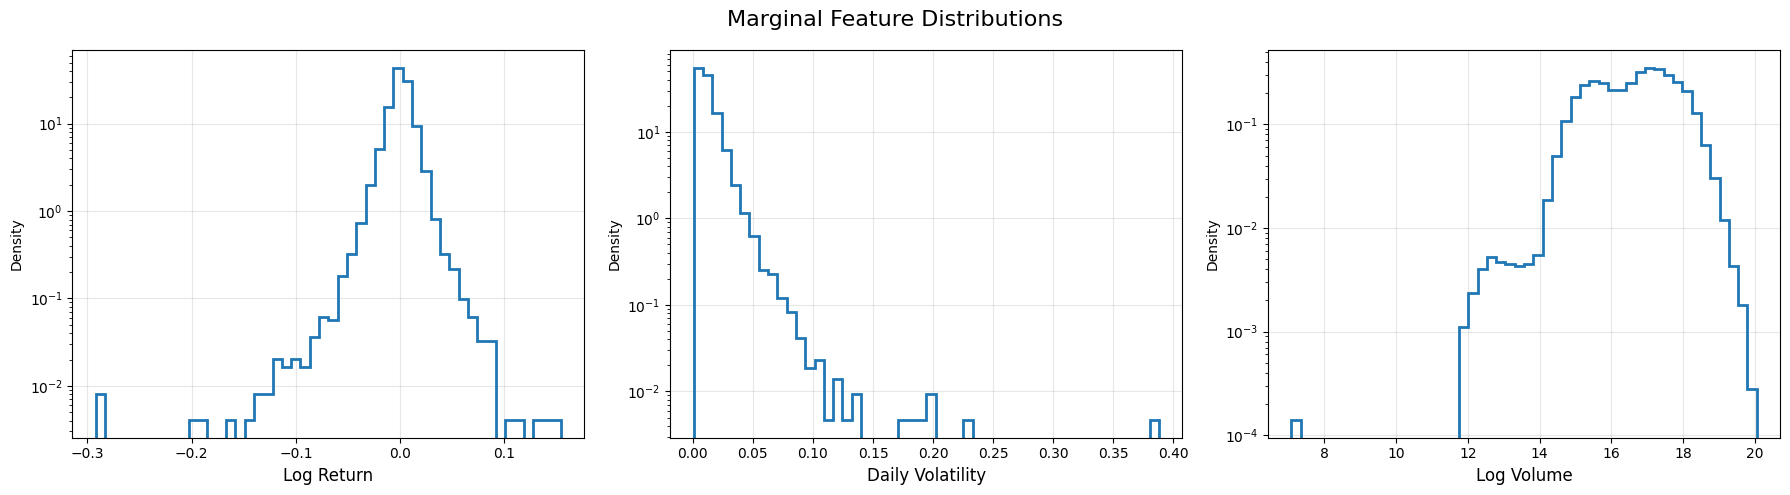

In [4]:
fig, ax = plt.subplots(ncols=3, figsize=(18, 5))


concat_data = financial_data.reshape(-1, n_features)

feature_names = [
    "Log Return",
    "Daily Volatility",
    "Log Volume"
]

for i in range(3):
    ax[i].hist(
        concat_data[:, i],
        bins=50,
        density=True,
        histtype="step",
        linewidth=2,
        label="Historical"
    )


    ax[i].set_xlabel(feature_names[i], fontsize=12)
    ax[i].set_ylabel("Density")
    ax[i].set_yscale("log")
    ax[i].grid(alpha=0.3)

plt.suptitle("Marginal Feature Distributions", fontsize=16)
plt.tight_layout()



In [5]:


mean_per_feature = financial_data.mean(axis=(0, 1))
std_per_feature = financial_data.std(axis=(0, 1))

normed_financial_data = (
    financial_data - mean_per_feature
) / std_per_feature


print("Means:", normed_financial_data.mean(axis=(0, 1)))
print("Standard deviations:", normed_financial_data.std(axis=(0, 1)))

Means: [-1.1029121e-09  8.1615497e-08 -6.5512978e-07]
Standard deviations: [0.99999994 1.         0.99999994]


## Forward diffusion

Primero analicemos el modelo de difusión que será la base de este tutorial. El principio fundamental de los modelos de difusión es añadir ruido progresivamente a la dos datos originales de la siguiente forma:

$q(z_t|z_{t-1}) = \mathcal{N}(z_t;\sqrt{\alpha_t} z_{t-1}, \beta_t)$

Donde la razón entre señal y ruido (signal to noise ratio) $SNR(t) = \alpha_t / \beta_t^2$ es estrictamente decreciente en cada iteración $t$. Lo anterior formaliza la idea de que $z_t$ cada vez tenga más ruido. La forma en la que $\beta_t$ cambia a través de las iteraciones lo llamaremos "variance schedule".

En este taller, trabajaremos una forma particular del modelo de difusión conocida como "variance-preserving", en la cual se establece la relación $\alpha_t = 1 - \beta_t$. Ahora, podemos obtener una iteración arbitraria $x_t$ a partir de $x_0$ de forma cerrada como se muestra a continuación:

$q(x_t|x_0) = \mathcal{N}(x_t;\sqrt{\bar{\alpha}_t}x_0, 1 - \bar{\alpha}_t)$

Donde $ \bar{\alpha}_t = \prod_{s=1}^t \alpha_s$

En las siguientes celdas podrán escribir el código necesario para llevar a cabo este proceso de difusión:

In [6]:
def beta_t(t: jnp.array,
           min_variance: float = 1e-4,
           max_variance: float = 0.02) -> jnp.array:
    """Linear variance schedule."""
    return min_variance + (max_variance - min_variance) * (t / 100.0)


def alpha_t(t: jnp.array,
            min_variance: float = 1e-4,
            max_variance: float = 0.02) -> jnp.array:
    """Variance-preserving schedule."""
    return 1.0 - beta_t(t, min_variance, max_variance)


def alpha_t_bar(t_n: int,
                t_N: int = 100,
                min_variance: float = 1e-4,
                max_variance: float = 0.02) -> float:
    """Cumulative product of alpha_t from t=0 to t=t_n."""
    times = jnp.arange(t_N + 1)
    alphas = alpha_t(times, min_variance, max_variance)
    alpha_bar = jnp.cumprod(alphas)
    return alpha_bar[t_n]


def forward_diffusion(x: jnp.array,
                      t_n: jnp.array,
                      t_N: int,
                      key: jnp.array) -> jnp.array:
    """Sample x_t directly from x_0."""
    eps = jax.random.normal(key, shape=x.shape)

    alpha_bar = jax.vmap(alpha_t_bar, in_axes=(0, None, None, None))(
        t_n, t_N, 1e-4, 0.02
    )

    alpha_bar = alpha_bar[None, None, :]          # (1,1,n_times)

    return (
        jnp.sqrt(alpha_bar) * x[:, :, None]
        + jnp.sqrt(1.0 - alpha_bar) * eps[:, :, None]
    )

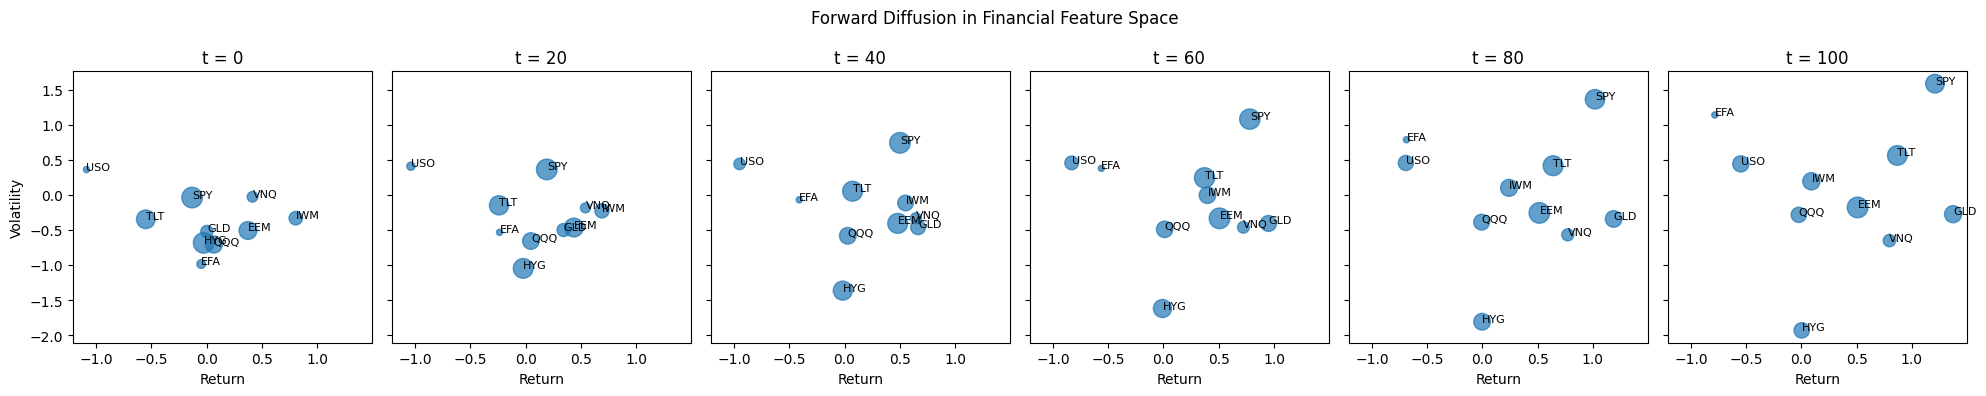

In [10]:
times = jnp.arange(0, 101, 20)

key = jax.random.PRNGKey(0)
t_N = 100

noisy_samples = forward_diffusion(
    normed_financial_data[0],
    times,
    t_N,
    key
)

fig, axes = plt.subplots(
    1,
    len(times),
    figsize=(20, 4),
    sharex=True,
    sharey=True
)

for i, t in enumerate(times):

    sample = noisy_samples[:, :, i]

    returns = sample[:, 0]
    volatility = sample[:, 1]
    volume = sample[:, 2]




    sizes = 200 * (volume - volume.min()) / (
        volume.max() - volume.min() + 1e-8
    ) + 20


    axes[i].scatter(
        returns,
        volatility,
        s=sizes,
        alpha=0.7
    )

    # Label each asset
    for x, y, label in zip(returns, volatility, tickers):
        axes[i].text(
            x,
            y,
            label,
            fontsize=8
        )

    axes[i].set_title(f"t = {t}")
    axes[i].set_xlabel("Return")

axes[0].set_ylabel("Volatility")

plt.suptitle("Forward Diffusion in Financial Feature Space")
plt.tight_layout()
plt.show()

## Eliminando el ruido del proceso de difusión
Ahora, entrenemos una red neuronal que aprenda a eliminar el ruido del proceso de difusión.

Para hacer esto, ela función de pérdida está definida por:

$L(x) = \langle w(t) || \epsilon - \hat{\epsilon}_\theta(x_t,t)|| \rangle $

Donde $\epsilon$ es el ruido que verdaderamente se agregó en el proceso y $hat{\epsilon}_\theta(x_t,t)$ es el ruido que se estima con la red neuronal. Dependiendo del peso $w(t)$ que escojamos, la función de pérdida será máxima verosimilitud o máxima verosimilitud con diferentes niveles de ruido. Por ahora, implementaremos un modelo de difusión simple con $w(t)=1$.

Para este ejemplo, la arquitectura de red neuronal que implementaremos será un multilayer perceptron. Sin embargo, pueden intentar diferentes arquitectura y ver esto cómo afecta el resultado del taller, por ejemplo, utilizando una red neuronal basada en grafos.

In [ ]:
# let's flatten the particle data to work with an MLP
# Flatten each trading day into a single vector
flattened_financial_data = normed_financial_data.reshape(
    len(normed_financial_data),
    -1
)
class MLP(nn.Module):
    """ A simple MLP in Flax. This is the noise-prediction network.
    """
    hidden_dim: int = 32
    out_dim: int = 2
    n_layers: int = 2

    @nn.compact
    def __call__(self, x):
        for _ in range(self.n_layers):
            x = nn.Dense(features=self.hidden_dim)(x)
            x = nn.gelu(x)
        x = nn.Dense(features=self.out_dim)(x)
        return x

noise_prediction_nn = MLP(hidden_dim=1024, out_dim=n_assets*n_features, n_layers=5)

# the noise prediction neural network will take as input an array of features per particle,
# of shape (n_particles*n_features,) and the diffusion time t, and return the predicted noise
# at that time step

# Let's initialize the network with some random data, of size 10
t_n = jnp.arange(10)[:, None]

params = noise_prediction_nn.init(
    key,
    jnp.concatenate(
        [
            flattened_financial_data[:10],
            t_n / t_N
        ],
        axis=-1
    )
)


In [ ]:
# Now let's define the loss function

def weight(t):
    return 1.


@partial(jax.jit, static_argnums=(3,))
def loss_fn(params: Dict, x: jnp.array, t_n: jnp.array, noise_prediction_nn: "nn.Module", key: jnp.array)->float:
    """ Loss function for the diffusion model

    Args:
        params (Dict): parameters of the noise prediction neural network
        x (jnp.array): point cloud data
        t_n (jnp.array): time steps to evaluate the diffusion model at
        noise_prediction_nn (nn.Module): noise prediction neural network
        key (jnp.array): jax random key

    Returns:
        float: reconstruction error loss
    """
    # sample some noise
    eps = jax.random.normal(key, shape=x.shape)
    alpha_t_bar_array = jax.vmap(alpha_t_bar, in_axes=(0,None,None,None))(t_n, t_N, 1e-4, 0.02)
    x_t = jnp.sqrt(alpha_t_bar_array) * x + jnp.sqrt(1 - alpha_t_bar_array) * eps
    eps_pred = noise_prediction_nn.apply(
    params,
    jnp.concatenate([x_t, t_n / t_N], axis=-1)
)
    return weight(t_n / t_N) * jnp.mean((eps - eps_pred) ** 2)


Ahora entrenemos el modelo.

In [ ]:
opt = optax.adam(learning_rate=3e-4)
opt_state = opt.init(params)

In [ ]:
n_steps = 5_000
n_batch = 128
t_N = 100

with trange(n_steps) as steps:
    for step in steps:

        # Sample a random mini-batch of trading days
        key, subkey = jax.random.split(key)

        idx = jax.random.choice(
            key,
            len(flattened_financial_data),
            shape=(n_batch,)
        )

        x_batch = flattened_financial_data[idx]

        # Sample a random diffusion time for each trading day
        t_n_batch = jax.random.choice(
            key,
            t_N,
            shape=(x_batch.shape[0], 1)
        )

        # Compute loss and gradients
        loss, grads = jax.value_and_grad(loss_fn)(
            params,
            x_batch,
            t_n_batch,
            noise_prediction_nn,
            key,
        )

        # Gradient update
        updates, opt_state = opt.update(grads, opt_state, params)
        params = optax.apply_updates(params, updates)

        steps.set_postfix(loss=float(loss))

100%|██████████| 5000/5000 [14:09<00:00,  5.89it/s, loss=0.4]


## Generando muestras

Para generar muestras a partir de ruido utilizaremos el concepto de "ancestral sampling", el cual utiliza como punto de partida la generación de una variable aleatoria normal estándar (la llamaremos prior) y de manera autorregresiva reconstruiremos el proceso de difusión de la siguiente forma:

$x_{t-1} = \frac{1}{\sqrt{\alpha_t}} \left( x_t - \frac{\beta_t}{\sqrt{1-\bar{\alpha}_t}} \hat{\epsilon}_\theta (x_t, t) \right) + \sigma_t z $

Donde $z \sim \mathcal{N}(0,1)$ y $\sigma_t^2 = \frac{1 - \bar{\alpha}_{t-1}}{1 - \bar{\alpha}_t} \beta_t$

In [ ]:
def generate_single_sample(noise_prediction_nn, params, key, t_N=100,):
    x_t = jax.random.normal(key, (n_assets*n_features,))

    for t_i in range(t_N, 0, -1):
        key, _ = jax.random.split(key)
        z = jax.random.normal(key, shape=x_t.shape)

        t = (t_i / t_N)
        t = jnp.atleast_1d(t)
        eps_pred = noise_prediction_nn.apply(
    params,
    jnp.concatenate([x_t[None, :], t.reshape(1, 1)], axis=-1)
)[0]#TODO: implement the call to the noise prediction neural network, with the correct input
        alpha = alpha_t(t_i)
        alpha_bar = alpha_t_bar(t_i)
        alpha_bar_prev = alpha_t_bar(t_i - 1)
        beta = beta_t(t_i)
        sigma_t = jnp.sqrt(
    ((1 - alpha_bar_prev) /
     (1 - alpha_bar))
    * beta
)#TODO: compute the sigma_t value, as described above

        x_t = (
    (1 / jnp.sqrt(alpha))
    * (
        x_t
        - (beta / jnp.sqrt(1 - alpha_bar))
        * eps_pred
    )
    + sigma_t * z
)#TODO: implement ancestral sampling

    return x_t


key = jax.random.PRNGKey(42)
single_sample = generate_single_sample(noise_prediction_nn, params, key, t_N=100,)

,Return,Volatility,Log Volume
SPY,-0.3093,-0.0958,1.0857
QQQ,-0.1643,-0.0549,0.1400
IWM,0.2364,0.1306,-0.6903
EFA,-0.0725,-0.5852,0.5020
EEM,0.8461,-0.0749,-0.3819
TLT,0.7648,0.1389,0.8711
HYG,0.3959,-0.2656,1.0794
GLD,0.2730,0.0315,-0.6251
USO,0.2680,0.6701,-1.4123
VNQ,-0.1220,0.5767,-1.3203


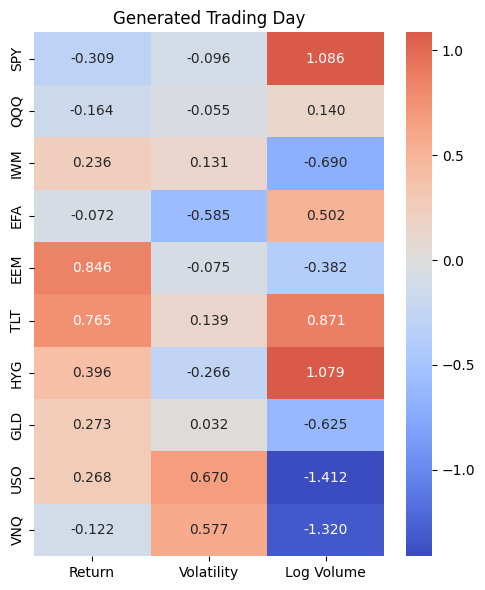

In [ ]:
x_sample = single_sample.reshape((n_assets, n_features))



feature_names = ["Return", "Volatility", "Log Volume"]

sample_df = pd.DataFrame(
    x_sample,
    index=tickers,
    columns=feature_names
)

display(sample_df.round(4))

plt.figure(figsize=(5,6))

sns.heatmap(
    sample_df,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".3f"
)

plt.title("Generated Trading Day")
plt.tight_layout()
plt.show()

In [ ]:
# Now let's vectorize this to draw lots of samples at once super fast
sample_fn = partial(generate_single_sample, noise_prediction_nn, params, t_N=50)

n_samples = 1000
sample_key = jax.random.split(key, n_samples)
x_samples = jax.vmap(sample_fn)(sample_key)
x_samples = x_samples.reshape((n_samples, n_assets, n_features))
#x_samples = x_samples * std_per_feature + mean_per_feature

/tmp/ipykernel_1954/2108089111.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


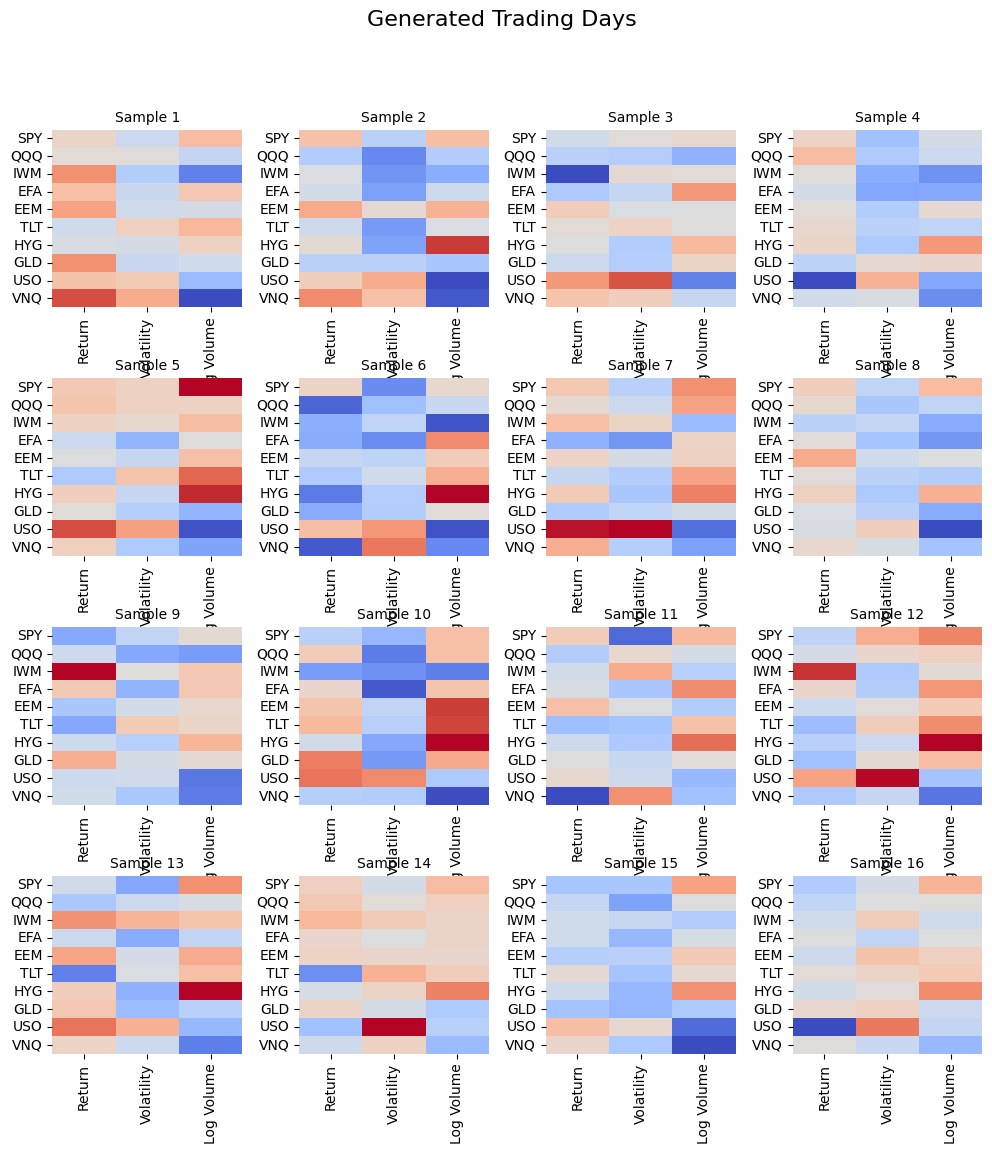

In [ ]:
# Let's visualize 16 generated trading days

feature_names = ["Return", "Volatility", "Log Volume"]

fig = plt.figure(figsize=(12, 12))
gs = GridSpec(4, 4, wspace=0.3, hspace=0.4)

for i in range(16):

    ax = fig.add_subplot(gs[i])

    sns.heatmap(
        x_samples[i],
        cmap="coolwarm",
        center=0,
        cbar=False,
        xticklabels=feature_names,
        yticklabels=tickers,
        ax=ax
    )

    ax.set_title(f"Sample {i+1}", fontsize=10)

plt.suptitle("Generated Trading Days", fontsize=16)
plt.tight_layout()

let's also compare them at the level of the feature's histograms

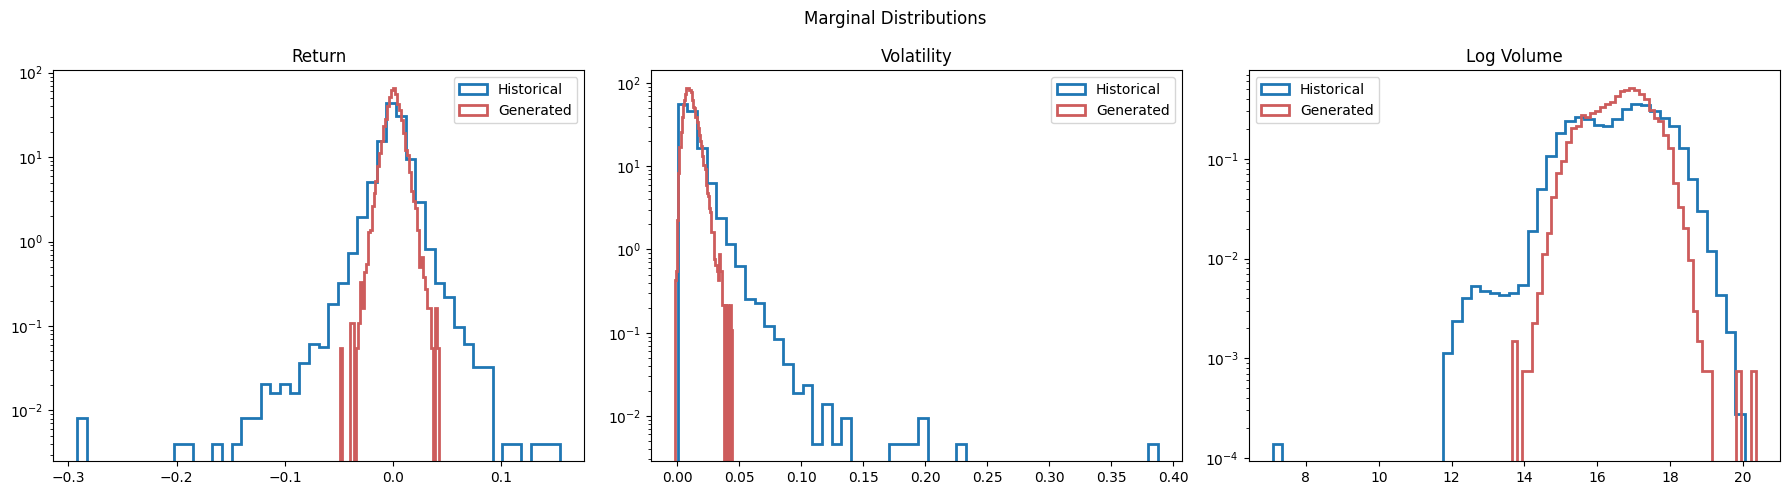

In [ ]:
real_data = financial_data.reshape(-1, n_features)
x_samples_scaled = x_samples * std_per_feature + mean_per_feature
generated_data = x_samples_scaled.reshape(-1, n_features)

feature_names = ["Return", "Volatility", "Log Volume"]

fig, ax = plt.subplots(1, 3, figsize=(18,5))

for i in range(3):

    ax[i].hist(
        real_data[:, i],
        bins=50,
        density=True,
        histtype="step",
        linewidth=2,
        label="Historical"
    )

    ax[i].hist(
        generated_data[:, i],
        bins=50,
        density=True,
        histtype="step",
        linewidth=2,
        label="Generated",
        color="indianred"
    )

    ax[i].set_title(feature_names[i])
    ax[i].set_yscale("log")
    ax[i].legend()

plt.suptitle("Marginal Distributions")
plt.tight_layout()



'#TODO' ¿En qué contexto de su trabajo cree que este tipo de modelos serían útiles? Defina cada observación que se quiere generar: ¿De qué unidades consta (como los ETFs)? ¿Qué características de cada unidad son relevantes para considerar (como el retorno, la volatilidad y el volumen)?

Como pueden observar, la media de cada una de las distribuciones marginales de las variables está muy bien aproximada. Sin embargo, parece ser que el riesgo de las colas de la distribución podría mejorar. ¿Qué se podría modificar en el flujo de trabajo del código para poder aumentar el ajustte en las colas?

### Bono: mejorando el ajuste de las colas

En la pregunta anterior notamos que, aunque las medias de las distribuciones generadas se ajustan bien a los datos históricos, las colas de la distribución no se ajustan tan bien. Una posible causa es que estemos usando **menos pasos de ancestral sampling (`t_N=50`) que los usados durante el entrenamiento (`t_N=100`)**: al discretizar más grueso el proceso inverso, se introduce error de discretización que afecta más a los eventos extremos (colas).

Probemos regenerar las muestras usando `t_N=100`, igual que en entrenamiento, y comparemos:

In [ ]:
# Repetimos la generación de muestras usando t_N=100 (igual que en entrenamiento)
sample_fn_bonus = partial(generate_single_sample, noise_prediction_nn, params, t_N=100)

n_samples = 1000
sample_key_bonus = jax.random.split(key, n_samples)
x_samples_bonus = jax.vmap(sample_fn_bonus)(sample_key_bonus)
x_samples_bonus = x_samples_bonus.reshape((n_samples, n_assets, n_features))

In [ ]:
x_samples_bonus_scaled = x_samples_bonus * std_per_feature + mean_per_feature
generated_data_bonus = x_samples_bonus_scaled.reshape(-1, n_features)

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

for i in range(3):

    ax[i].hist(
        real_data[:, i],
        bins=50,
        density=True,
        histtype="step",
        linewidth=2,
        label="Históricas"
    )

    ax[i].hist(
        generated_data[:, i],
        bins=50,
        density=True,
        histtype="step",
        linewidth=2,
        label="Generadas (t_N=50)",
        color="indianred"
    )

    ax[i].hist(
        generated_data_bonus[:, i],
        bins=50,
        density=True,
        histtype="step",
        linewidth=2,
        label="Generadas (t_N=100)",
        color="seagreen"
    )

    ax[i].set_title(feature_names[i])
    ax[i].set_yscale("log")
    ax[i].legend()

plt.suptitle("Efecto del número de pasos de sampling en el ajuste de las colas")
plt.tight_layout()
plt.show()